In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_sales.csv')

In [3]:
df["product_category"].value_counts()

product_category
electronics        8133
office supplies    4492
furniture          3279
appliances         1976
Name: count, dtype: int64

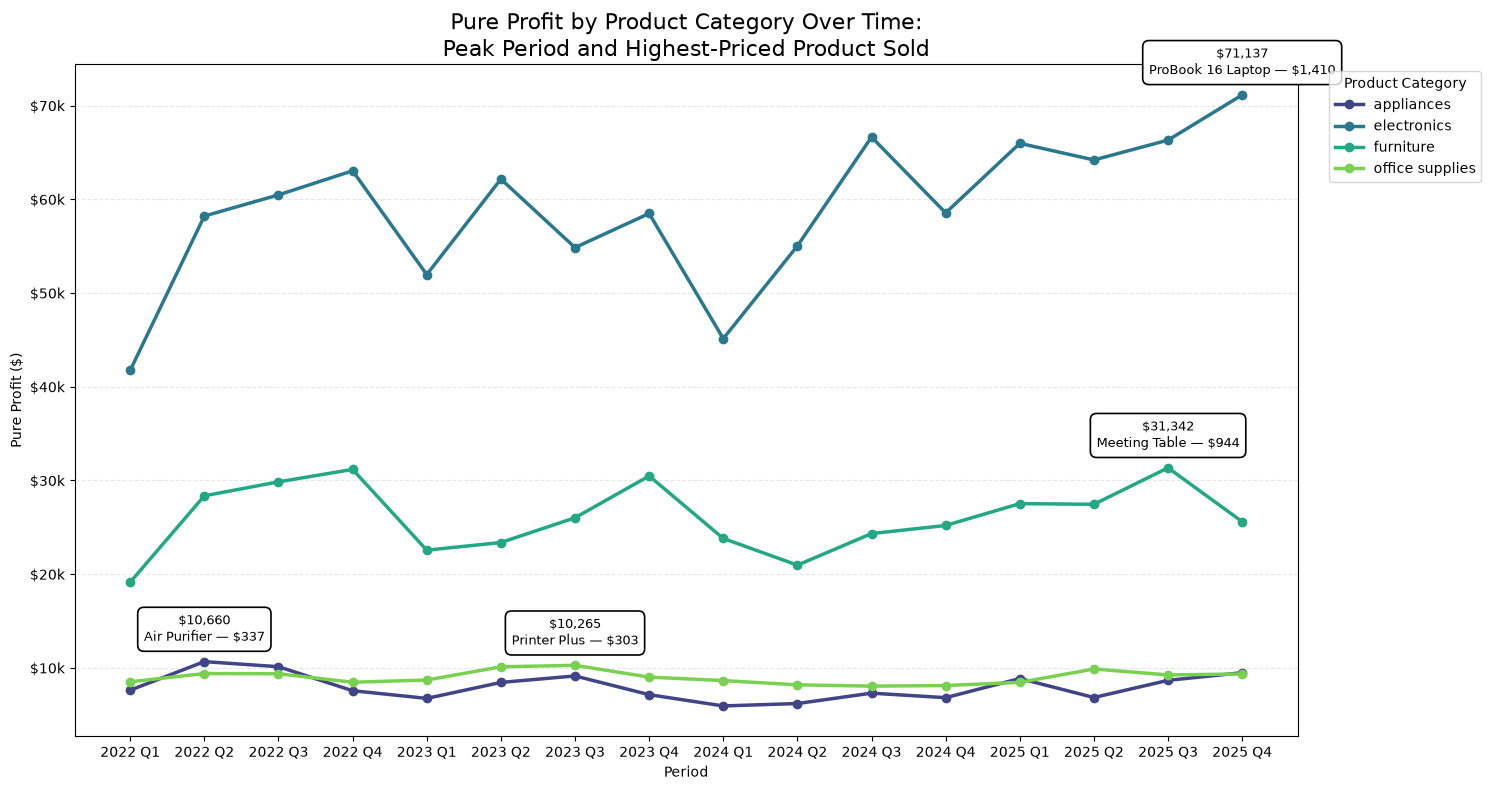

In [5]:
import matplotlib.patheffects as pe

df["pure_profit"] = df["sales_amount"] - df["cost_amount"]

df["period"] = (
    pd.to_datetime(df["order_date"]).dt.year.astype(str)
    + " Q"
    + pd.to_datetime(df["order_date"]).dt.quarter.astype(str)
)

profit_df = (
    df.groupby(["period", "product_category"], as_index=False)["pure_profit"]
      .sum()
)

periods = sorted(
    profit_df["period"].unique(),
    key=lambda x: (int(x[:4]), int(x[-1]))
)

plt.figure(figsize=(15, 8))

categories = profit_df["product_category"].unique()
colors = sns.color_palette("viridis", len(categories))

for category, color in zip(categories, colors):

    data = profit_df[profit_df["product_category"] == category]

    y = [
        data.loc[data["period"] == p, "pure_profit"].sum()
        for p in periods
    ]

    plt.plot(
        periods, y,
        marker="o",
        linewidth=2.5,
        label=category,
        color=color
    )

    # Peak
    peak_idx = max(range(len(y)), key=lambda i: y[i])
    peak_period = periods[peak_idx]
    peak_profit = y[peak_idx]

    peak_products = df[
        (df["product_category"] == category) &
        (df["period"] == peak_period)
    ]

    product = peak_products.loc[
        peak_products["unit_price"].idxmax()
    ]

    label = (
        f"${peak_profit:,.0f}\n"
        f"{product['product_name']} — ${product['unit_price']:,.0f}"
    )

    plt.annotate(
        label,
    xy=(peak_period, peak_profit),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    color="black",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black",
        linewidth=1.2
        ),
        
    )

plt.title(
    "Pure Profit by Product Category Over Time:\n"
    "Peak Period and Highest-Priced Product Sold",
    fontsize=16
)
plt.xlabel("Period")
plt.ylabel("Pure Profit ($)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(title="Product Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: (
            f"${x/1_000_000:.1f}M"
            if abs(x) >= 1_000_000
            else f"${x/1_000:.0f}k"
        )
    )
)

plt.tight_layout()
plt.show()